In [1]:
print("My Project Started")

My Project Started


# Import the requierd libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

In [3]:
import pandas as pd

data = pd.read_csv("Social_Network_Ads.csv")
data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Social_Network_Ads.csv'

# Check your current folder

In [4]:
import os
print(os.getcwd())

C:\Users\ASUS\Documents\Insurance_project


# See all files in that folder

In [5]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Untitled.ipynb']


# Send me the output

In [6]:
print(os.getcwd())
print(os.listdir())

C:\Users\ASUS\Documents\Insurance_project
['.ipynb_checkpoints', 'Untitled.ipynb']


In [7]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Social_Network_Ads (1).csv', 'Untitled.ipynb']


# check the dataset structure

In [8]:
import pandas as pd

data = pd.read_csv("Social_Network_Ads (1).csv")

data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [10]:
data.shape

(400, 3)

 # Check for Missing Values

In [11]:
data.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

# Purchase Count Graph

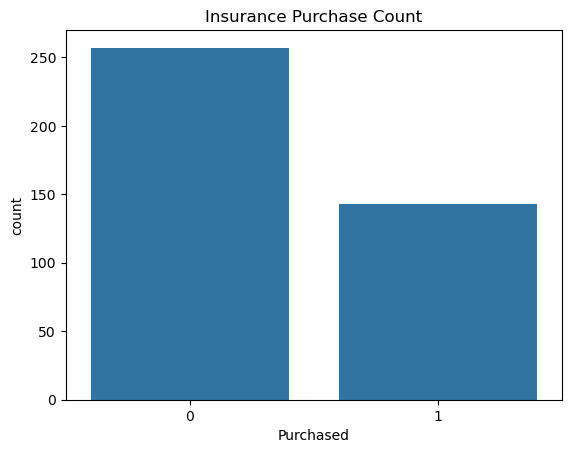

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Purchased', data=data)
plt.title("Insurance Purchase Count")
plt.show()

# Age vs Salary Graph

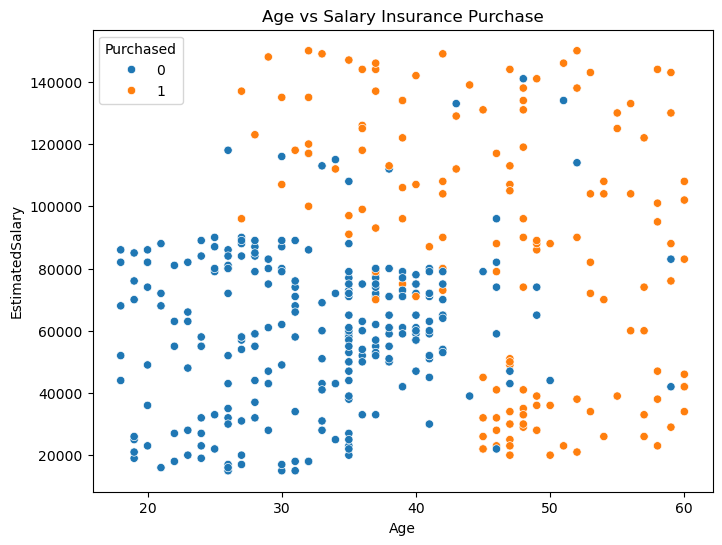

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    data=data
)

plt.title("Age vs Salary Insurance Purchase")
plt.show()

# Prepare Features and Target

In [14]:
X = data[['Age', 'EstimatedSalary']]
y = data['Purchased']

print(X.head())
print(y.head())

   Age  EstimatedSalary
0   19            19000
1   35            20000
2   26            43000
3   27            57000
4   19            76000
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


# Split Data into Training and Testing Sets

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (300, 2)
Testing Data: (100, 2)


# Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(X_train[:5])

[[ 1.8925893   1.52189404]
 [ 0.1250379   0.03213212]
 [ 0.9106163  -1.31157471]
 [-1.34792161 -1.48684082]
 [-0.169554   -0.58129926]]


# Train Your First AI Model (Logistic Regression)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.86


# K-Nearest Neighbors (KNN) 

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.93


# Support Vector Machine (SVM)

In [19]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.93


# Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.83


# Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.89


# Compare All Models

In [22]:
import pandas as pd

results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        acc_lr,
        acc_knn,
        acc_svm,
        acc_dt,
        acc_rf
    ]
})

print(results)

             Algorithm  Accuracy
0  Logistic Regression      0.86
1                  KNN      0.93
2                  SVM      0.93
3        Decision Tree      0.83
4        Random Forest      0.89


# Find the Best Model

In [23]:
print(results.sort_values(by='Accuracy', ascending=False))

             Algorithm  Accuracy
1                  KNN      0.93
2                  SVM      0.93
4        Random Forest      0.89
0  Logistic Regression      0.86
3        Decision Tree      0.83


# Predict Project Scenarios

In [24]:
test_cases = [
    [30, 87000],
    [40, 0],
    [40, 100000],
    [50, 0],
    [18, 0],
    [22, 600000],
    [35, 2500000],
    [60, 100000000]
]

for case in test_cases:
    scaled_case = sc.transform([case])
    prediction = knn.predict(scaled_case)
    print(f"Age={case[0]}, Salary={case[1]} --> Purchased={prediction[0]}")

Age=30, Salary=87000 --> Purchased=0
Age=40, Salary=0 --> Purchased=0
Age=40, Salary=100000 --> Purchased=1
Age=50, Salary=0 --> Purchased=1
Age=18, Salary=0 --> Purchased=0
Age=22, Salary=600000 --> Purchased=1
Age=35, Salary=2500000 --> Purchased=1
Age=60, Salary=100000000 --> Purchased=1


E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Create Accuracy Graph

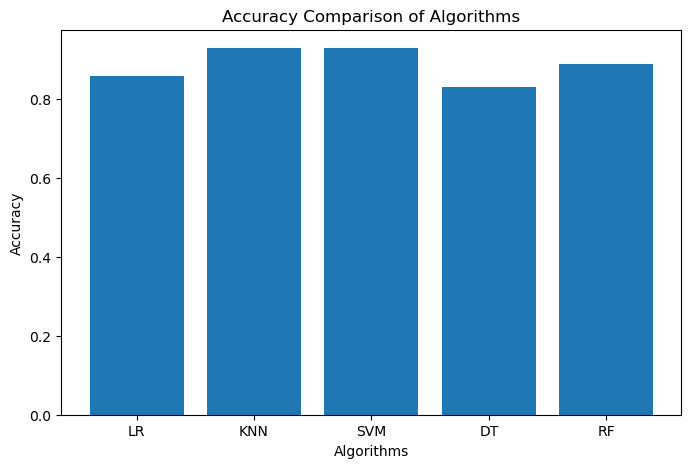

In [26]:
import matplotlib.pyplot as plt

algorithms = ['LR', 'KNN', 'SVM', 'DT', 'RF']
accuracies = [acc_lr, acc_knn, acc_svm, acc_dt, acc_rf]

plt.figure(figsize=(8,5))
plt.bar(algorithms, accuracies)

plt.title('Accuracy Comparison of Algorithms')
plt.xlabel('Algorithms')
plt.ylabel('Accuracy')

plt.show()

# Create Confusion Matrix for Best Model (KNN)

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_knn)

print(cm)

[[59  4]
 [ 3 34]]


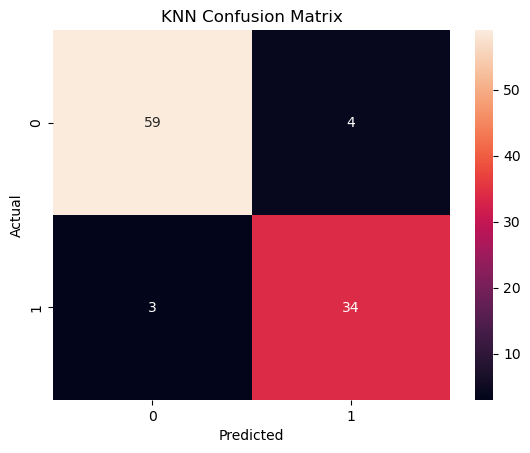

In [28]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
test_cases = [
    [30, 87000],
    [40, 0],
    [40, 100000],
    [50, 0],
    [18, 0],
    [22, 600000],
    [35, 2500000],
    [60, 100000000]
]

for case in test_cases:
    scaled_case = sc.transform([case])
    prediction = knn.predict(scaled_case)
    print(f"Age={case[0]}, Salary={case[1]} --> Purchased={prediction[0]}")

Age=30, Salary=87000 --> Purchased=0
Age=40, Salary=0 --> Purchased=0
Age=40, Salary=100000 --> Purchased=1
Age=50, Salary=0 --> Purchased=1
Age=18, Salary=0 --> Purchased=0
Age=22, Salary=600000 --> Purchased=1
Age=35, Salary=2500000 --> Purchased=1
Age=60, Salary=100000000 --> Purchased=1


E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
E:\Neela Doc\anaconda navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Age Distribution Graph

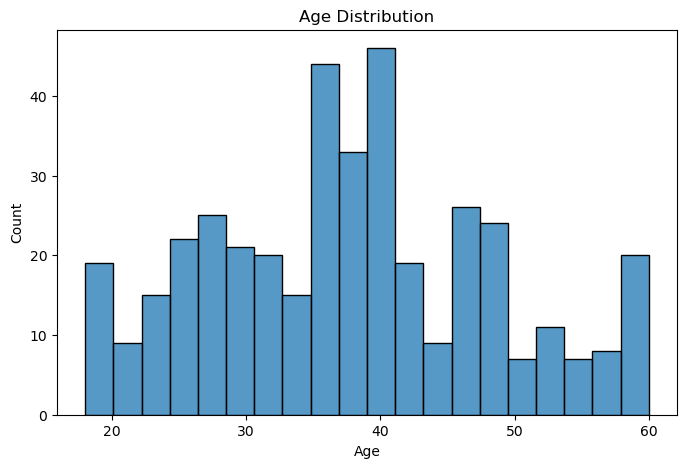

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Salary Distribution Graph

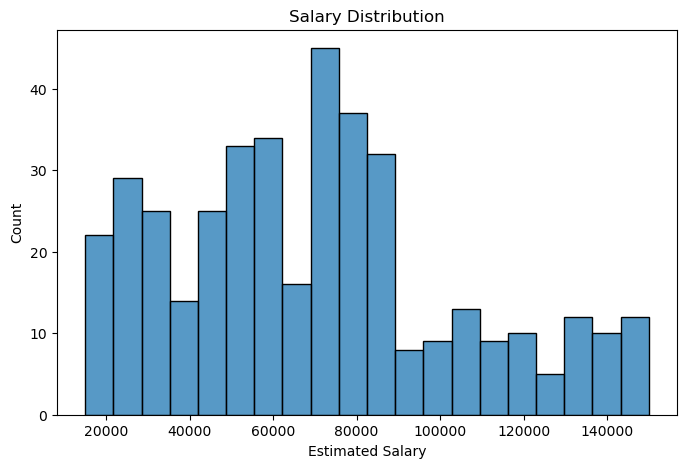

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(data['EstimatedSalary'], bins=20)
plt.title("Salary Distribution")
plt.xlabel("Estimated Salary")
plt.ylabel("Count")
plt.show()